Steps to follow:

1. Business Objective

2. Load Market Data

3. Calculate Returns

4. Estimate Volatility

5. Price Option

6. Calculate Greeks

7. Stock Price Sensitivity

8. Volatility Sensitivity

9. Scenario Analysis

10. Risk Summary Dashboard

11. Key Findings

Objective:

Estimate the fair value of a European Call Option on Reliance Industries using Black-Scholes.

Assess:

- Option Value
- Delta Risk
- Volatility Risk
- Scenario Risk

In [75]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [76]:
ticker='^NSEI'

nifty=yf.download(ticker, start='2016-06-25', end='2026-06-26')
nifty

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2016-06-27,8094.700195,8120.649902,8039.350098,8039.350098,162500
2016-06-28,8127.850098,8146.350098,8086.850098,8096.049805,170400
2016-06-29,8204.000000,8212.400391,8157.649902,8173.100098,147000
2016-06-30,8287.750000,8308.150391,8242.099609,8260.250000,279400
2016-07-01,8328.349609,8356.750000,8308.650391,8313.049805,165500
...,...,...,...,...,...
2026-06-19,24013.099609,24047.199219,23901.900391,23991.199219,447900
2026-06-22,24102.900391,24168.050781,24073.150391,24106.599609,252800


In [77]:
nifty.tail(10)

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2026-06-12,23622.900391,23645.349609,23313.900391,23412.550781,351900
2026-06-15,23853.900391,24011.400391,23817.800781,23984.849609,398900
2026-06-16,23989.150391,24002.599609,23888.199219,23923.900391,327300
2026-06-17,24085.699219,24108.199219,23969.699219,24044.500000,352700
2026-06-18,24168.000000,24189.250000,24036.949219,24073.800781,340000
2026-06-19,24013.099609,24047.199219,23901.900391,23991.199219,447900
2026-06-22,24102.900391,24168.050781,24073.150391,24106.599609,252800
2026-06-23,23824.099609,24135.500000,23784.949219,24071.300781,340100


In [78]:
nifty['returns']=np.log(nifty['Close']/nifty['Close'].shift(1))
nifty.dropna()

Price,Close,High,Low,Open,Volume,returns
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,
Date,,,,,,
2016-06-28,8127.850098,8146.350098,8086.850098,8096.049805,170400,0.004087
2016-06-29,8204.000000,8212.400391,8157.649902,8173.100098,147000,0.009325
2016-06-30,8287.750000,8308.150391,8242.099609,8260.250000,279400,0.010157
2016-07-01,8328.349609,8356.750000,8308.650391,8313.049805,165500,0.004887
2016-07-04,8370.700195,8398.450195,8364.700195,8376.750000,154200,0.005072
...,...,...,...,...,...,...
2026-06-19,24013.099609,24047.199219,23901.900391,23991.199219,447900,-0.006430
2026-06-22,24102.900391,24168.050781,24073.150391,24106.599609,252800,0.003733


In [79]:
nifty['returns'].mean()*252

0.11148337674539778

In [80]:
daily_vol=nifty['returns'].std()
daily_vol

0.010284196073890571

In [81]:
annual_vol=daily_vol*np.sqrt(252)  #same as daily_vol*(252)**0.5
annual_vol

0.1632565514744478

Volatility answers:

How unpredictable is the stock?

-> the stock is annually 16% volatile.

In [82]:
from scipy.stats import norm

In [83]:
#black-scholes function for call price:

def call_price(S,K,T,r,sigma):

    d1= (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*(T**0.5))
    d2= d1- sigma*T**0.5

    call= (S*norm.cdf(d1))-(K*np.exp(-r*T)*norm.cdf(d2))

    return call

In [84]:
#give the inputs and accordingly will get output via function

S= nifty['Close'].iloc[-1]  # .iloc[-1] is basically to select the very last (most recent) closing price

K= 23900 # K>S i.e., select from NSE option chain and pricing call at OTM
# K<S # deep ITM
# K=S #ATM

T= 5/365 # in years
r=0.06 # govt yield or bond
sigma= 0.0975 # historical volatility from model or implied volatility from NSE chart

In [85]:
option_value= call_price(S,K,T,r,sigma)
option_value

Ticker
^NSEI    218.687817
Name: 2026-06-25 00:00:00, dtype: float64

So, 

-the current price is the latest closing price here which 29th May

-if we adjust K below/above/remain same to S, accordingly call option will be priced at ITM/OTM/ATM respectively.

Option value/premium = intrinsic value + time value

In [86]:
def call_delta(S,K,T,r,sigma):

    d1= (np.log(S/K)+(r+(sigma**2)/2)*T)/(sigma*(T**0.5))

    return norm.cdf(d1)  #this is delta

In [87]:
delta= call_delta(S,K,T,r,sigma)
delta

array([0.74146094])

#FIRST RISK MEASURE

If stock increase by 100, call price will increase by X

# how option price change due to price sensitivity

In [88]:
# Extract the raw number
current_S = float(nifty['Close'].iloc[-1])  #the recent closing price

# now let say price vary from -20% to +20% of the raw_S, consider 20 such prices
stock_range = np.arange(current_S * 0.8, current_S * 1.2, 10)
stock_range

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19932\1005691030.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_S = float(nifty['Close'].iloc[-1])  #the recent closing price


array([19244.8, 19254.8, 19264.8, 19274.8, 19284.8, 19294.8, 19304.8,
       19314.8, 19324.8, 19334.8, 19344.8, 19354.8, 19364.8, 19374.8,
       19384.8, 19394.8, 19404.8, 19414.8, 19424.8, 19434.8, 19444.8,
       19454.8, 19464.8, 19474.8, 19484.8, 19494.8, 19504.8, 19514.8,
       19524.8, 19534.8, 19544.8, 19554.8, 19564.8, 19574.8, 19584.8,
       19594.8, 19604.8, 19614.8, 19624.8, 19634.8, 19644.8, 19654.8,
       19664.8, 19674.8, 19684.8, 19694.8, 19704.8, 19714.8, 19724.8,
       19734.8, 19744.8, 19754.8, 19764.8, 19774.8, 19784.8, 19794.8,
       19804.8, 19814.8, 19824.8, 19834.8, 19844.8, 19854.8, 19864.8,
       19874.8, 19884.8, 19894.8, 19904.8, 19914.8, 19924.8, 19934.8,
       19944.8, 19954.8, 19964.8, 19974.8, 19984.8, 19994.8, 20004.8,
       20014.8, 20024.8, 20034.8, 20044.8, 20054.8, 20064.8, 20074.8,
       20084.8, 20094.8, 20104.8, 20114.8, 20124.8, 20134.8, 20144.8,
       20154.8, 20164.8, 20174.8, 20184.8, 20194.8, 20204.8, 20214.8,
       20224.8, 2023

In [89]:
option_prices1=[]

for stock in stock_range:
    call_value_price_sensitivity= call_price(stock,K,T,r,sigma)  #using cell 11 & 12, we can change variable value(K,T,r,sigma) as per requirement
    
    option_prices1.append(call_value_price_sensitivity)  #.append() = this allow each element to be in the exisitng list altogether

option_prices1

[5.83209190065588e-79,
 1.385040540161144e-78,
 3.2810375326795596e-78,
 7.753041630445272e-78,
 1.827455679129715e-77,
 4.296719686722512e-77,
 1.0077301020748042e-76,
 2.3575998176191934e-76,
 5.501944410886377e-76,
 1.2808083767991123e-75,
 2.974236990950082e-75,
 6.889568579751111e-75,
 1.5919708897696298e-74,
 3.669496215940913e-74,
 8.437379442519502e-74,
 1.935263541513823e-73,
 4.427979779878761e-73,
 1.0106614509660683e-72,
 2.301133985814381e-72,
 5.226558537608072e-72,
 1.1842107737700312e-71,
 2.676597334938853e-71,
 6.035030697686242e-71,
 1.3574376691879755e-70,
 3.045831264759238e-70,
 6.817715442141379e-70,
 1.522371138140424e-69,
 3.391192200962253e-69,
 7.535915292902019e-69,
 1.6706016181179387e-68,
 3.6945761006348783e-68,
 8.151034010004934e-68,
 1.7939845623583088e-67,
 3.938983309230514e-67,
 8.628008313522363e-67,
 1.885382512167504e-66,
 4.110100358790328e-66,
 8.938629482064344e-66,
 1.9393514702149513e-65,
 4.197693361507792e-65,
 9.064315482675946e-65,
 1.95

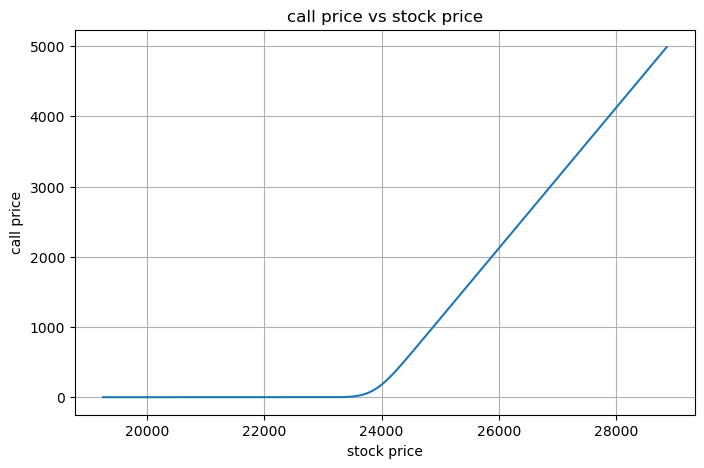

In [90]:
# plot to visualize the relationship between stock prices and option value

plt.figure(figsize=(8,5))
plt.plot(stock_range, option_prices1)
plt.title('call price vs stock price')
plt.xlabel('stock price')
plt.ylabel('call price')
plt.grid()
plt.show()  

# option price change due to volatility senstivity

In [91]:
vol_range=np.arange(0.10,0.60,0.02)
vol_range

array([0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22, 0.24, 0.26, 0.28, 0.3 ,
       0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52,
       0.54, 0.56, 0.58])

In [92]:
option_prices2=[]

for volatility in vol_range:
    call_value_volatility_senstivity=call_price(S,K,T,r,volatility)
    
    option_prices2.append(call_value_volatility_senstivity)
    
option_prices2

[Ticker
 ^NSEI    220.976111
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    239.98829
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    259.906687
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    280.413751
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    301.322981
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    322.51838
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    343.924285
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    365.489352
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    387.177555
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    408.962898
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    430.826161
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    452.752831
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    474.731747
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 ^NSEI    496.754186
 Name: 2026-06-25 00:00:

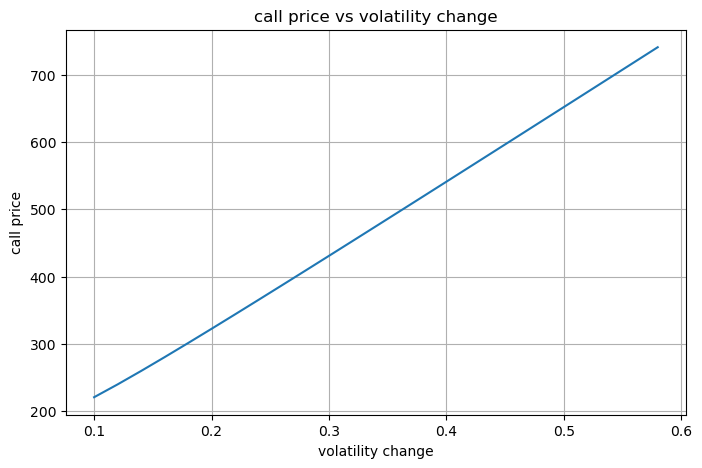

In [93]:
# plot to visualize the relationship between stock prices and option value

plt.figure(figsize=(8,5))
plt.plot(vol_range, option_prices2)
plt.title('call price vs volatility change')
plt.xlabel('volatility change')
plt.ylabel('call price')
plt.grid()
plt.show()  

SO the above is vega risk

# scenarios analysis

In [94]:
# create various scenarios(worst/best/no change) to get the idea of how my portfolio would get changed 

scenarios=[-0.30,-0.10,0,0.10,0.30]

market crashed by -30% / -10% or got a push by +30% / +10%

In [95]:
new_S = S # recent closing price i.e, 29th may

resulted_price=[]

for s in scenarios:
    new_stock= new_S*(1+s)
    
    new_option_price=call_price(new_stock,K,T,r,sigma)
    
    pnl= new_option_price-option_value
    
    resulted_price.append([s,new_stock,new_option_price,pnl])
    
resulted_price

[[-0.3,
  Ticker
  ^NSEI    16839.2
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    3.012569e-205
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI   -218.687817
  Name: 2026-06-25 00:00:00, dtype: float64],
 [-0.1,
  Ticker
  ^NSEI    21650.4
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    1.272488e-16
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI   -218.687817
  Name: 2026-06-25 00:00:00, dtype: float64],
 [0,
  Ticker
  ^NSEI    24056.0
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    218.687817
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    0.0
  Name: 2026-06-25 00:00:00, dtype: float64],
 [0.1,
  Ticker
  ^NSEI    26461.6
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    2581.235765
  Name: 2026-06-25 00:00:00, dtype: float64,
  Ticker
  ^NSEI    2362.547948
  Name: 2026-06-25 00:00:00, dtype: float64],
 [0.3,
  Ticker
  ^NSEI    31272.8
  Name: 2026-06-25 00:00:00, dtyp

So the resulted_price is basically - 

market change by---> new stock price----> new call price ----> profit or loss comparing with the intial call price

In [96]:
#create dataframe for the above result

scenario_df= pd.DataFrame(resulted_price,columns=['scenario','stock price','option price', 'PnL'])

In [97]:
scenario_df

,scenario,stock price,option price,PnL
0,-0.3,Ticker ^NSEI 16839.2 Name: 2026-06-25 00:00...,Ticker ^NSEI 3.012569e-205 Name: 2026-06-25...,Ticker ^NSEI -218.687817 Name: 2026-06-25 00...
1,-0.1,Ticker ^NSEI 21650.4 Name: 2026-06-25 00:00...,Ticker ^NSEI 1.272488e-16 Name: 2026-06-25 ...,Ticker ^NSEI -218.687817 Name: 2026-06-25 00...
2,0.0,Ticker ^NSEI 24056.0 Name: 2026-06-25 00:00...,Ticker ^NSEI 218.687817 Name: 2026-06-25 00...,"Ticker ^NSEI 0.0 Name: 2026-06-25 00:00:00,..."
3,0.1,Ticker ^NSEI 26461.6 Name: 2026-06-25 00:00...,Ticker ^NSEI 2581.235765 Name: 2026-06-25 0...,Ticker ^NSEI 2362.547948 Name: 2026-06-25 0...
4,0.3,Ticker ^NSEI 31272.8 Name: 2026-06-25 00:00...,Ticker ^NSEI 7392.435765 Name: 2026-06-25 0...,Ticker ^NSEI 7173.747948 Name: 2026-06-25 0...


# Dashboard 

In [98]:
dashboard= pd.DataFrame({
    'Metrics':['Current stock price','volatiltiy','option value','delta'],
    'Value':[round(S,2),round(sigma,3),round(option_value,2),np.round(delta,4)]
})

dashboard

,Metrics,Value
0,Current stock price,Ticker ^NSEI 24056.0 Name: 2026-06-25 00:00...
1,volatiltiy,0.098
2,option value,Ticker ^NSEI 218.69 Name: 2026-06-25 00:00:...
3,delta,[0.7415]


In [99]:
option_value
market_premium=292.15

error_pct = (abs(option_value-market_premium)/market_premium)
error_pct

Ticker
^NSEI    0.251454
Name: 2026-06-25 00:00:00, dtype: float64

In [100]:
# raw_S = float(nifty['Close'].iloc[-1])
# raw_option_value= float(option_value)
# raw_strike=float(K)
# raw_delta= float(delta[0])
# raw_error= float(error_pct)

# print("="*50)
# print("OPTION RISK DASHBOARD")
# print("="*50)

# print(f"Stock Price : {raw_S:.2f}")
# print(f"Strike Price : {raw_strike:.2f}")
# print(f"Volatility : {sigma:.2%}")    #this is based on IV.
# print(f"Model price : {raw_option_value:.2f}")
# print(f"Market premium : {market_premium:.2f}")
# print(f"Error : {raw_error:.2%}")
# print(f"Delta : {raw_delta:.2f}")

# print("="*50)

Key findings: 

## Option Pricing & Market Risk – Key Learnings

### 1. Option value is driven by five key inputs

* Black-Scholes prices an option using **Stock Price (S), Strike Price (K), Time to Expiry (T), Risk-Free Rate (r), and Volatility (σ)**.
* Among these, **volatility is the most uncertain and influential input**.

---

### 2. Historical Volatility and Implied Volatility answer different questions

* **Historical Volatility (HV):** How much the stock moved in the past.
* **Implied Volatility (IV):** What volatility the market is currently pricing into the option premium.
* HV is useful for risk analysis; IV is generally preferred for option pricing.

---

### 3. Market price comes first, IV comes later

* Option premiums on NSE are determined by **buyers and sellers trading in the market**.
* IV is not observed directly; it is **reverse-engineered from the market option price using Black-Scholes**.

---

### 4. Black-Scholes does not determine market prices

* The model provides a **theoretical fair value**.
* Actual market prices are influenced by supply-demand, liquidity, hedging activity, market sentiment, and event expectations.

---

### 5. Model validation is more important than model implementation

* A pricing model should be compared against actual market premiums.
* Validation can be performed using:

  * Pricing difference
  * Error %
  * Mean Absolute Error (MAE) across multiple contracts

---

### 6. Deep ITM, near-expiry options behave differently

* Most of their value comes from **intrinsic value**.
* Time value becomes very small.
* As a result, option prices become **less sensitive to volatility assumptions**.

---

### 7. Volatility matters most for ATM options

* At-the-money options have significant time value.
* Small changes in volatility can materially impact option prices.
* These contracts are more useful for studying volatility effects.

---

### 8. Greeks measure risk, not valuation

* **Delta:** Sensitivity to stock price changes.
* **Vega:** Sensitivity to volatility changes.
* Greeks help quantify risk exposure rather than determine fair value.

---

### 9. Stress testing changes the perspective

* Pricing answers:

  > "What is the option worth today?"
* Stress testing answers:

  > "What happens if markets move against me?"

This is the mindset used in Market Risk teams.

---

### 10. A good risk analyst focuses on drivers, not just outputs

* The objective is not merely to calculate an option price.
* The objective is to understand:

  * Why the option has that value.
  * Which risk factors drive the value.
  * How sensitive the value is to market changes.
  * When and why the model differs from market prices.

---

**Market Data → Volatility Estimation → Option Valuation → Greeks → Scenario Analysis → Model Validation → Risk Reporting**

which is exactly the thought process expected in many Market Risk and Risk Analytics role.


# Let's automate the above workflow, so that one command will give me entire summary of the option 

In [101]:
#automated the "time to expiry" calculation

from datetime import datetime
def time_to_expiry(expiry):   #expiry_date format should be YYYY-MM-DD and returns time_to_expiry in years
    today=datetime.today()
    expiry_date= datetime.strptime(expiry, "%Y-%m-%d")
    
    days=(expiry_date-today).days  #(.days) is to convert into days
    
    if days<1:  #to avoid any negative/zero divisor if date is 0/negative
        days=1
    
    return days/365

In [133]:
def run_option_analysis(ticker,strike,expiry,premium,IV,r=0.065):    #r is the risk-free rate which is govt bond's yield
    #-------------------------------------
    #Download Market Data
    #-------------------------------------
    
    data=yf.download(ticker,period='1y', progress=False)
    data['returns']=np.log(data['Close']/data['Close'].shift(1))
    daily_vol=data['returns'].std()
    annual_vol=daily_vol*np.sqrt(252)
    S= float(data['Close'].iloc[-1])  #latest closing price as of now
    K=strike
    sigma= IV  #IV is more preferrable than annual_vol
    T=time_to_expiry(expiry)
    market_premium= premium
    
    #-------------------------------------
    #Price Option
    #-------------------------------------
    
    model_price=call_price(S,K,T,r,sigma)  #this is same as option_value in line#12
    delta_value=call_delta(S,K,T,r,sigma)  #this is same as above delta in line#13
    error_percentage = (abs(model_price-market_premium)/market_premium)
    
    #-------------------------------------
    #Dashboard
    #-------------------------------------
    
    print('='*50)
    print('OPTION RISK DASHBOARD')
    print('='*50)
    
    print(f"Ticker        : {ticker}")
    print(f"Stock Price   : {S:.2f}")
    print(f"Strike Price  : {K}")
    print(f"Volatility    : {sigma:.2%}")
    print(f"Time to Expiry: {T:.4f} years")
    print(f"Delta         : {delta_value:.2f}")
    print(f"Model Price   : {model_price:.2f}")
    print(f"Market premium : {market_premium:.2f}")
    print(f"Error%         : {error_percentage:.2%}")
    
    if error_percentage<0.03:
        print("Excellent model validation")
    elif error_percentage<0.07:
        print("Reasonable agreement")
    else:
        print("Model deviates materially")
    
    print('='*50)
    
    return{                        #this is store the value as dictionary to call out quickly any component under result
       "ticker":ticker,
        "stock":S,
        "strike":K,
        "sigma":sigma,
        "T":T,
        "market_premium":premium,
        "call_price":model_price,
        "call_delta":delta_value,
        "error":error_percentage
    }

# this is the main command for risk dashboard

In [134]:
run_option_analysis(
    ticker="RELIANCE.NS",
    strike=1300,
    expiry="2026-08-25",
    premium=46.25,
    IV=0.2304
)

OPTION RISK DASHBOARD
Ticker        : RELIANCE.NS
Stock Price   : 1294.90
Strike Price  : 1300
Volatility    : 23.04%
Time to Expiry: 0.1096 years
Delta         : 0.53
Model Price   : 41.43
Market premium : 46.25
Error%         : 10.43%
Model deviates materially


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19932\681620740.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S= float(data['Close'].iloc[-1])  #latest closing price as of now


{'ticker': 'RELIANCE.NS',
 'stock': 1294.9000244140625,
 'strike': 1300,
 'sigma': 0.2304,
 'T': 0.1095890410958904,
 'market_premium': 46.25,
 'call_price': 41.427262547701275,
 'call_delta': 0.5318785698611723,
 'error': 0.10427540437402648}

In [135]:
pip install openai


  Obtaining dependency information for openai from https://files.pythonhosted.org/packages/f1/b0/2291689e3ec4723fbf5bbf3b54afcd7b160f9ddc98ca7aedfd0132af5677/openai-2.45.0-py3-none-any.whl.metadata
  Obtaining dependency information for httpx<1,>=0.23.0 from https://files.pythonhosted.org/packages/2a/39/e50c7c3a983047577ee07d2a9e53faf5a69493943ec3f6a384bdc792deb2/httpx-0.28.1-py3-none-any.whl.metadata
  Obtaining dependency information for jiter<1,>=0.10.0 from https://files.pythonhosted.org/packages/64/ec/2feb893eb330bd69b413866f4d5daada33c3962f1c6f270c91ca2d87fdf9/jiter-0.16.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for typing-extensions<5,>=4.14 from https://files.pythonhosted.org/packages/49/d3/b8441a820a491ddfc024b0b0cf0393375b75ea13866d9c66727e54c2fc80/typing_extensions-4.16.0-py3-none-any.whl.metadata
  Obtaining dependency information for httpcore==1.* from https://files.pythonhosted.org/packages/7e/f5/f66802a942d491edb555dd61e3a9961140fd64c90bce1